# CPM + FiPy RD model

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Dict

import matplotlib.animation as animation
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches

from fipy import CellVariable, Grid2D, TransientTerm, DiffusionTerm


# (1) parameters

In [23]:
# --------------------------
# Spatial / temporal units
# --------------------------
dx_um = 50.0                 # micrometers per pixel
dx_mm = dx_um / 1000.0       # mm per pixel
pixel_area_mm2 = dx_mm**2

nx, ny = 50, 50
dx = dy = dx_mm

dt_pde_min = 0.05            # minutes (3 seconds per PDE solve)
pde_substeps = 10            # solve the PDE 10 times per macro step
dt_macro_min = dt_pde_min * pde_substeps # one macro step corresponds to 0.5 min of biological time

n_macro = 200                # macro steps
MCS_per_macro = 40000        # CPM attempts per macro step

# --------------------------
# Cell types (biological)
# --------------------------
MEDIUM = 0 
OPC    = 1
OLIGO  = 2
MICRO  = 3

# Visualization label for mutant OPC (optional)
OPC_MUT = 4

type_names = {MEDIUM:"Medium/ECM", OPC:"OPC", OLIGO:"Oligodendrocyte", MICRO:"Microglia"}

# --------------------------
# Colors / legends (IMPORTANT: order matches numeric labels)
# --------------------------
type_colors = {
    MEDIUM:"black",
    OPC:"deepskyblue",
    OLIGO:"gold",
    MICRO:"tomato",
    OPC_MUT:"purple",
}
cmap_cells = ListedColormap([type_colors[i] for i in [MEDIUM, OPC, OLIGO, MICRO, OPC_MUT]])
norm_cells = BoundaryNorm([-0.5,0.5,1.5,2.5,3.5,4.5], cmap_cells.N)
legend_handles = [
    mpatches.Patch(color=type_colors[OPC],     label="OPC (WT)"),
    mpatches.Patch(color=type_colors[OPC_MUT], label="OPC* (mutant)"),
    mpatches.Patch(color=type_colors[OLIGO],   label="Oligodendrocyte"),
    mpatches.Patch(color=type_colors[MICRO],   label="Microglia"),
]

# --------------------------
# Neighborhood (Moore 8-neighbor)
# --------------------------
nbrs = [(1,0),(-1,0),(0,1),(0,-1),
        (1,1),(1,-1),(-1,1),(-1,-1)]
def in_bounds(x,y): return 0 <= x < nx and 0 <= y < ny # prevent copying outside the grid boundary

# --------------------------
# CPM energy parameters
# --------------------------
J = np.zeros((4,4), dtype=float) # contact energies - penalize boundaries between different types 
J[MEDIUM, OPC]   = J[OPC, MEDIUM]   = 10.0 # higher J - dislike contact
J[MEDIUM, OLIGO] = J[OLIGO, MEDIUM] = 12.0
J[MEDIUM, MICRO] = J[MICRO, MEDIUM] = 11.0
J[OPC, OLIGO]    = J[OLIGO, OPC]    = 6.0 #lower J - adhesion
J[OPC, MICRO]    = J[MICRO, OPC]    = 9.0
J[OLIGO, MICRO]  = J[MICRO, OLIGO]  = 9.0

lambda_V = {OPC: 0.8, OLIGO: 2.5, MICRO: 2.0} # stiffness: larger - harder to grow
V0 = {OPC: 45, OLIGO: 55, MICRO: 45} # target area
V_div_target = 1.4 * V0[OPC] # division threshold

T = 30.0

# Chemotaxis (OPC towards G)
lambda_chem = {OPC: 180.0, OLIGO: 0.0, MICRO: 0.0} # migration up the gradient 
G_sat = 0.5 # saturation of G
def chi_G(g): return g/(1.0 + g/G_sat)

# OPC growth (target volume increase)
growth_coeff = 3.0
K_I_grow = 0.7 # suppression of I on OPC target-volume growth 

# --------------------------
# PDE parameters (mm^2/min, 1/min, a.u./min)
# --------------------------
D_I = 0.03 # diffusion of coefficients (relatively high now to speed up)
D_G = 0.02

k_I = np.log(2)/15.0 # time of clearance to half-lives: 15 min
k_G = np.log(2)/20.0

# OPC-mediated clearance of I (additional sink term)
eta_I_default = 0.06  # 1/min
eta_I_strong = 0.03  # strong: weaker local resolution

s_G = 0.06 # production of local G

# Growth factor uptake by OPC (MM with competitive inhibition by I)
Vmax_wt = 0.12
Vmax_mut = 0.192
Km   = 0.50
# larger K means weaker competitive inhibition by I, which reduces the artificial G-storage rebound in strong inflammation
Ki_default  = 0.50
Ki_strong = 0.80

# --------------------------
# GRN inside OPC: r, p, q (q induced by I inhibits r)
# Make differentiation easier (lower threshold and hold time)
# --------------------------
alpha_r = 1.6
gamma_r = 0.7
alpha_p = 1.0
gamma_p = 0.5

alpha_q = 1.2
gamma_q = 0.8

# mild v.s. strong inflammation sensitivity in the GRN
K_I_q_default   = 0.8
K_I_q_strong   = 0.6

m_I = 2
K_q = 0.8
h_q = 2

K_G = 0.6
n_hill = 3
def H_G(G):
    return (G**n_hill) / (K_G**n_hill + G**n_hill + 1e-12)
def H_I(I, K_I_q):
    return (I**m_I) / (K_I_q**m_I + I**m_I + 1e-12)

p_th = 0.25
tau_hold = 1.5

# microglia resolution threshold
R_resolve_default = 0.55
R_resolve_strong = 0.75


mu = 0.02

sI_mild   = 0.05
sI_strong = 0.12

np.random.seed(1)
print(f"Domain: {nx}x{ny} pixels, dx={dx_um:.0f} um ({dx:.3f} mm).")
print(f"Macro dt={dt_macro_min:.2f} min, steps={n_macro}, total time={dt_macro_min*n_macro/60:.2f} h")


Domain: 50x50 pixels, dx=50 um (0.050 mm).
Macro dt=0.50 min, steps=200, total time=1.67 h


In [24]:
def get_regime_params(regime="mild"):
    if regime == "mild":
        return {
            "s_I": sI_mild,
            "eta_I": eta_I_default,
            "Ki": Ki_default,
            "K_I_q": K_I_q_default,
            "R_resolve": R_resolve_default,
            "t_init_active": 20.0
        }
    elif regime == "strong":
        return {
            "s_I": sI_strong,
            "eta_I": eta_I_strong,
            "Ki": Ki_strong,
            "K_I_q": K_I_q_strong,
            "R_resolve": R_resolve_strong,
            "t_init_active": 40.0
        }

# (2) CPM state and initialization

In [25]:
@dataclass
class Cell:
    cid: int
    ctype: int
    genotype: int = 0
    r: float = 0.0
    p: float = 0.0
    q: float = 0.0
    p_hold: int = 0

def make_disk(sigma, cid, center, radius):
    cx, cy = center
    xs = np.arange(nx)[:,None]
    ys = np.arange(ny)[None,:]
    mask = (xs-cx)**2 + (ys-cy)**2 <= radius**2
    sigma[mask] = cid

def random_centers(n, margin=5, seed=1):
    rng = np.random.default_rng(seed)
    centers = []
    for _ in range(n):
        centers.append((
            int(rng.integers(margin, nx-margin)),
            int(rng.integers(margin, ny-margin))
        ))
    return centers

def init_cells(n_opc=5, n_oligo=8, n_micro=6, radius=3, seed=1):
    sigma = np.zeros((nx, ny), dtype=np.int32)
    cells: Dict[int, Cell] = {}
    cid = 1

    # make centers
    oligo_centers = random_centers(n_oligo, seed=seed+1)
    opc_centers   = random_centers(n_opc,   seed=seed+2)
    micro_centers = random_centers(n_micro, seed=seed+3)

    for c in oligo_centers:
        make_disk(sigma, cid, c, radius=radius)
        cells[cid] = Cell(cid=cid, ctype=OLIGO); cid += 1

    for c in opc_centers:
        make_disk(sigma, cid, c, radius=radius)
        cells[cid] = Cell(cid=cid, ctype=OPC, genotype=0); cid += 1

    for c in micro_centers:
        make_disk(sigma, cid, c, radius=radius)
        cells[cid] = Cell(cid=cid, ctype=MICRO); cid += 1

    return sigma, cells

def compute_volumes(sigma, cells):
    vols = {cid:0 for cid in cells.keys()}
    ids, counts = np.unique(sigma, return_counts=True)
    for i,c in zip(ids, counts):
        if i != 0 and int(i) in vols:
            vols[int(i)] = int(c)
    return vols

def sigma_to_type_grid(sigma, cells):
    tg = np.zeros_like(sigma, dtype=np.int32)
    for cid, cell in cells.items():
        tg[sigma==cid] = cell.ctype
    return tg

def sigma_to_display_grid(sigma, cells):
    tg = np.zeros_like(sigma, dtype=np.int32)
    for cid, cell in cells.items():
        if cell.ctype == OPC and cell.genotype == 1:
            tg[sigma==cid] = OPC_MUT
        else:
            tg[sigma==cid] = cell.ctype
    return tg

def cell_centroid(sigma, cid):
    pts = np.argwhere(sigma==cid)
    if len(pts)==0:
        return None
    return (int(np.round(pts[:,0].mean())), int(np.round(pts[:,1].mean())))

sigma, cells = init_cells(n_opc=15, n_oligo=6, n_micro=6, radius=2)
volumes = compute_volumes(sigma, cells)
Vt_cell = {cid: float(V0[cells[cid].ctype]) for cid in cells.keys()}


# (3) CPM ΔH (boundary + volume + chemotaxis)

In [26]:
def boundary_energy_at(x,y, sigma_grid, cells):
    sid = int(sigma_grid[x,y])
    stype = MEDIUM if sid==0 else cells[sid].ctype
    E = 0.0
    for dx_,dy_ in nbrs:
        xn, yn = x+dx_, y+dy_
        nid = 0 if not in_bounds(xn,yn) else int(sigma_grid[xn,yn])
        ntype = MEDIUM if nid==0 else cells[nid].ctype
        if nid != sid:
            E += J[stype, ntype]
    return E

def delta_boundary_energy(x,y, source_id, sigma_grid, cells):
    affected = {(x,y)}
    for dx_,dy_ in nbrs:
        xn, yn = x+dx_, y+dy_
        if in_bounds(xn,yn):
            affected.add((xn,yn))
    E_old = sum(boundary_energy_at(a,b, sigma_grid, cells) for a,b in affected)
    old_val = sigma_grid[x,y]
    sigma_grid[x,y] = source_id
    E_new = sum(boundary_energy_at(a,b, sigma_grid, cells) for a,b in affected)
    sigma_grid[x,y] = old_val
    return E_new - E_old

def delta_volume_energy(source_id, target_id, cells, volumes, Vt_cell):
    dH = 0.0
    if target_id != 0:
        ttype = cells[target_id].ctype
        lam = lambda_V[ttype]
        Vt  = Vt_cell[target_id]
        Vold = volumes[target_id]
        dH += lam*((Vold-1 - Vt)**2 - (Vold - Vt)**2)
    if source_id != 0:
        stype = cells[source_id].ctype
        lam = lambda_V[stype]
        Vt  = Vt_cell[source_id]
        Vold = volumes[source_id]
        dH += lam*((Vold+1 - Vt)**2 - (Vold - Vt)**2)
    return dH

def delta_chemotaxis(x,y, xn,yn, source_id, G_arr, cells):
    if source_id == 0:
        return 0.0
    stype = cells[source_id].ctype
    lam = lambda_chem.get(stype, 0.0)
    if lam == 0.0:
        return 0.0
    return -lam * (chi_G(G_arr[x,y]) - chi_G(G_arr[xn,yn]))

def cpm_sweep(sigma, cells, volumes, Vt_cell, G_arr, n_attempts):
    for _ in range(n_attempts):
        x = np.random.randint(0,nx)
        y = np.random.randint(0,ny)
        dx_,dy_ = nbrs[np.random.randint(0,len(nbrs))]
        xn, yn = x+dx_, y+dy_
        if not in_bounds(xn,yn):
            continue
        source_id = int(sigma[xn,yn])
        target_id = int(sigma[x,y])
        if source_id == target_id:
            continue

        dH  = delta_boundary_energy(x,y, source_id, sigma, cells)
        dH += delta_volume_energy(source_id, target_id, cells, volumes, Vt_cell)
        dH += delta_chemotaxis(x,y, xn,yn, source_id, G_arr, cells)

        if dH <= 0.0 or np.random.rand() < np.exp(-dH/T):
            sigma[x,y] = source_id
            if target_id != 0: volumes[target_id] -= 1
            if source_id != 0: volumes[source_id] += 1

## (4) FiPy PDEs and coupling maps

In [27]:
mesh = Grid2D(dx=dx, dy=dy, nx=nx, ny=ny)
I = CellVariable(name="I", mesh=mesh, value=0.0)
G = CellVariable(name="G", mesh=mesh, value=0.2)

def build_maps_from_cpm(sigma, cells, micro_active, I_arr, G_arr, regime_params):
    tg = sigma_to_type_grid(sigma, cells)
    micro = (tg == MICRO).astype(float)
    oligo = (tg == OLIGO).astype(float)
    opc_mask = (tg == OPC)

    s_I_value = regime_params["s_I"]
    eta_I = regime_params["eta_I"]
    Ki = regime_params["Ki"]

    A = np.zeros_like(micro)
    for cid, cell in cells.items():
        if cell.ctype == MICRO and micro_active.get(cid, 0) == 1:
            A[sigma == cid] = 1.0

    S_I = s_I_value * micro * A
    S_G = s_G * oligo

    Vmax_map = np.zeros_like(G_arr)
    for cid, cell in cells.items():
        if cell.ctype == OPC:
            Vmax_map[sigma == cid] = (Vmax_mut if cell.genotype == 1 else Vmax_wt)

    denom = Km * (1.0 + I_arr / (Ki + 1e-12)) + G_arr
    U_G = opc_mask.astype(float) * (Vmax_map * G_arr / (denom + 1e-12))

    U_I = eta_I * opc_mask.astype(float) * I_arr

    return S_I, S_G, U_G, U_I


def solve_pdes(I, G, sigma, cells, micro_active, regime_params, dt):
    I_arr = np.array(I.value).reshape((nx, ny), order='F')
    G_arr = np.array(G.value).reshape((nx, ny), order='F')

    S_I, S_G, U_G, U_I = build_maps_from_cpm(
        sigma, cells, micro_active, I_arr, G_arr, regime_params
    )

    SI = CellVariable(mesh=mesh, value=S_I.reshape(-1, order='F'))
    SG = CellVariable(mesh=mesh, value=S_G.reshape(-1, order='F'))
    UG = CellVariable(mesh=mesh, value=U_G.reshape(-1, order='F'))
    UI = CellVariable(mesh=mesh, value=U_I.reshape(-1, order='F'))

    eqI = TransientTerm() == DiffusionTerm(coeff=D_I) + SI - k_I * I - UI
    eqG = TransientTerm() == DiffusionTerm(coeff=D_G) + SG - UG - k_G * G

    eqI.solve(var=I, dt=dt)
    eqG.solve(var=G, dt=dt)

def get_fields(I, G):
    return (np.array(I.value).reshape((nx,ny), order='F'),
            np.array(G.value).reshape((nx,ny), order='F'))


# (5) growth/division/differentiation rules

In [28]:
def grn_update_opcs(sigma, cells, I_arr, G_arr, dt_min, regime_params):
    K_I_q = regime_params["K_I_q"]

    for cid, cell in cells.items():
        if cell.ctype != OPC:
            continue

        cxy = cell_centroid(sigma, cid)
        if cxy is None:
            continue

        x, y = cxy
        g_local = G_arr[x, y]
        i_local = I_arr[x, y]

        dq = alpha_q * H_I(i_local, K_I_q) - gamma_q * cell.q
        cell.q = max(0.0, cell.q + dt_min * dq)

        inhib = 1.0 / (1.0 + (cell.q / K_q) ** h_q)
        dr = alpha_r * H_G(g_local) * inhib - gamma_r * cell.r
        dp = alpha_p * cell.r - gamma_p * cell.p

        cell.r = max(0.0, cell.r + dt_min * dr)
        cell.p = max(0.0, cell.p + dt_min * dp)

        cell.p_hold = (cell.p_hold + 1) if (cell.p >= p_th) else 0

def opc_differentiate_by_grn(cells, Vt_cell, mutants_cannot_diff=True):
    for cid, cell in list(cells.items()):
        if cell.ctype != OPC:
            continue
        if mutants_cannot_diff and cell.genotype==1:
            continue
        if cell.p_hold >= tau_hold:
            cell.ctype = OLIGO
            Vt_cell[cid] = float(V0[OLIGO])


In [29]:
def differentiation_ratio(sigma, cells):
    tg = sigma_to_type_grid(sigma, cells)
    opc_px = float((tg==OPC).sum())
    ol_px  = float((tg==OLIGO).sum())
    denom = opc_px + ol_px
    return 0.0 if denom<=0 else ol_px/denom

def update_microglia_activation(cells, micro_active, Rdiff, regime_params, tmin):
    R_resolve = regime_params["R_resolve"]
    t_init_active = regime_params.get("t_init_active", 30.0)

    for cid, cell in cells.items():
        if cell.ctype != MICRO:
            continue

        if tmin < t_init_active:
            micro_active[cid] = 1
        else:
            if Rdiff >= R_resolve:
                micro_active[cid] = 0
            else:
                micro_active[cid] = 1


def microglia_activation_percent(cells, micro_active):
    micro_ids = [cid for cid, c in cells.items() if c.ctype == MICRO]
    if len(micro_ids) == 0:
        return 0.0
    active = sum(micro_active.get(cid, 0) for cid in micro_ids)
    return 100.0 * active / len(micro_ids)

def split_cell_pixels(sigma, cid):
    pts = np.argwhere(sigma==cid)
    if len(pts) < 16:
        return None
    cx, cy = int(np.round(pts[:,0].mean())), int(np.round(pts[:,1].mean()))
    left  = pts[pts[:,0] <= cx]
    right = pts[pts[:,0] >  cx]
    if len(left) < 6 or len(right) < 6:
        left  = pts[pts[:,1] <= cy]
        right = pts[pts[:,1] >  cy]
        if len(left) < 6 or len(right) < 6:
            return None
    return left, right

def add_cell(cells, volumes, Vt_cell, new_type, new_target, parent=None):
    new_id = max(cells.keys()) + 1
    if parent is None:
        cells[new_id] = Cell(cid=new_id, ctype=new_type)
    else:
        cells[new_id] = Cell(cid=new_id, ctype=new_type, genotype=parent.genotype, r=0.0, p=0.0, q=0.0, p_hold=0)
    volumes[new_id] = 0
    Vt_cell[new_id] = float(new_target)
    return new_id

def opc_growth_update(Vt_cell, sigma, cells, I_arr, G_arr):
    for cid, cell in cells.items():
        if cell.ctype != OPC:
            continue
        cxy = cell_centroid(sigma, cid)
        if cxy is None:
            continue
        x,y = cxy
        inc = growth_coeff * (G_arr[x,y]/(0.6 + G_arr[x,y])) * (1.0/(1.0 + I_arr[x,y]/K_I_grow))
        Vt_cell[cid] = min(V_div_target, Vt_cell[cid] + inc)

def opc_division_with_mutation(sigma, cells, volumes, Vt_cell):
    for cid, cell in list(cells.items()):
        if cell.ctype != OPC:
            continue
        if Vt_cell[cid] < V_div_target:
            continue
        if volumes[cid] < 0.9 * Vt_cell[cid]:
            continue
        split = split_cell_pixels(sigma, cid)
        if split is None:
            continue
        left, right = split
        new_id = add_cell(cells, volumes, Vt_cell, OPC, V0[OPC], parent=cell)
        if np.random.rand() < mu:
            cells[new_id].genotype = 1
        sigma[right[:,0], right[:,1]] = new_id
        volumes[cid] = int(len(left))
        volumes[new_id] = int(len(right))
        Vt_cell[cid] = float(V0[OPC])

def count_cells_by_type(cells):
    n_opc = sum(1 for c in cells.values() if c.ctype==OPC)
    n_ol  = sum(1 for c in cells.values() if c.ctype==OLIGO)
    n_mg  = sum(1 for c in cells.values() if c.ctype==MICRO)
    return n_opc, n_ol, n_mg


# (6) Runner

In [30]:
def run_sim(regime="mild", seed=1, make_gif=True, gif_path="sim.gif", frame_stride=5):
    np.random.seed(seed)
    regime_params = get_regime_params(regime)

    sigma, cells = init_cells()
    volumes = compute_volumes(sigma, cells)
    Vt_cell = {cid: float(V0[cells[cid].ctype]) for cid in cells.keys()}
    micro_active = {cid: 1 for cid, c in cells.items() if c.ctype == MICRO}

    I = CellVariable(name="I", mesh=mesh, value=0.0)
    G = CellVariable(name="G", mesh=mesh, value=0.2)

    t = []; meanI = []; meanG = []
    nOPC = []; nOL = []; nMG = []
    mg_pct = []
    frames = []

    tracked_opc = next((cid for cid, c in cells.items() if c.ctype == OPC), None)
    tr_t, tr_r, tr_p = [], [], []

    for step in range(n_macro):
        tmin = step * dt_macro_min
        for _ in range(pde_substeps):
            solve_pdes(I, G, sigma, cells, micro_active, regime_params, dt_pde_min)

        I_arr, G_arr = get_fields(I, G)

        cpm_sweep(sigma, cells, volumes, Vt_cell, G_arr, n_attempts=MCS_per_macro)

        grn_update_opcs(sigma, cells, I_arr, G_arr, dt_macro_min, regime_params)
        opc_differentiate_by_grn(cells, Vt_cell, mutants_cannot_diff=True)

        Rdiff = differentiation_ratio(sigma, cells)
        update_microglia_activation(cells, micro_active, Rdiff, regime_params,tmin)

        opc_growth_update(Vt_cell, sigma, cells, I_arr, G_arr)
        opc_division_with_mutation(sigma, cells, volumes, Vt_cell)

        t.append(tmin)
        meanI.append(float(I_arr.mean()))
        meanG.append(float(G_arr.mean()))
        a, b, c = count_cells_by_type(cells)
        nOPC.append(a); nOL.append(b); nMG.append(c)
        mg_pct.append(microglia_activation_percent(cells, micro_active))

        if tracked_opc is not None and tracked_opc in cells and cells[tracked_opc].ctype == OPC:
            tr_t.append(tmin)
            tr_r.append(cells[tracked_opc].r)
            tr_p.append(cells[tracked_opc].p)

        if make_gif and (step % frame_stride == 0 or step == n_macro - 1):
            tg = sigma_to_display_grid(sigma, cells)
            frames.append((tg.copy(), I_arr.copy(), G_arr.copy(), tmin))

    t = np.array(t)

    plt.figure(figsize=(6,3))
    plt.plot(t, meanI, label="mean I")
    plt.plot(t, meanG, label="mean G")
    plt.xlabel("time (min)"); plt.ylabel("a.u.")
    plt.title(f"Mean substrates ({regime} inflammation)")
    plt.legend(); plt.tight_layout(); plt.show()

    plt.figure(figsize=(6,3))
    plt.plot(t, nOPC, label="#OPC")
    plt.plot(t, nOL,  label="#Oligo")
    plt.plot(t, nMG,  label="#Microglia")
    plt.xlabel("time (min)"); plt.ylabel("count")
    plt.title("Cell counts over time")
    plt.legend(); plt.tight_layout(); plt.show()

    plt.figure(figsize=(6,3))
    plt.plot(t, mg_pct, label="microglia active (%)")
    plt.xlabel("time (min)"); plt.ylabel("%")
    plt.ylim(-5,105)
    plt.title("Microglia activation percentage")
    plt.legend(); plt.tight_layout(); plt.show()

    tr_t = np.array(tr_t); tr_r = np.array(tr_r); tr_p = np.array(tr_p)

    plt.figure(figsize=(7,3))
    plt.plot(tr_t, tr_r, label="tracked r(t)")
    plt.plot(tr_t, tr_p, label="tracked p(t)")
    plt.axhline(p_th, color="k", ls=":", label="p_th")
    plt.xlabel("time (min)"); plt.title("Tracked OPC GRN time-series")
    plt.legend(); plt.tight_layout(); plt.show()

    plt.figure(figsize=(5,4))
    plt.plot(tr_r, tr_p, marker="o", ms=2)
    plt.xlabel("r"); plt.ylabel("p")
    plt.title("Tracked OPC phase trajectory (r,p)")
    plt.tight_layout(); plt.show() 

    if make_gif:
        fig, axes = plt.subplots(1,3, figsize=(13,4))
        ax0, ax1, ax2 = axes

        im_cells = ax0.imshow(frames[0][0].T, origin="lower", cmap=cmap_cells, norm=norm_cells, interpolation="nearest")
        ax0.set_title("Cells + boundaries"); ax0.set_xticks([]); ax0.set_yticks([])
        ax0.legend(handles=legend_handles, loc="upper right", frameon=True)

        im_I = ax1.imshow(frames[0][1].T, origin="lower")
        ax1.set_title("I (a.u.)"); ax1.set_xticks([]); ax1.set_yticks([])
        fig.colorbar(im_I, ax=ax1, fraction=0.046)

        im_G = ax2.imshow(frames[0][2].T, origin="lower")
        ax2.set_title("G (a.u.)"); ax2.set_xticks([]); ax2.set_yticks([])
        fig.colorbar(im_G, ax=ax2, fraction=0.046)

        title = fig.suptitle("", fontsize=12)

        def update(i):
            tg, Iarr, Garr, tmin = frames[i]
            im_cells.set_data(tg.T)

            im_I.set_data(Iarr.T)
            im_G.set_data(Garr.T)
            im_I.set_clim(0.0, max(1e-6, np.percentile(Iarr, 99)))
            im_G.set_clim(0.0, max(1e-6, np.percentile(Garr, 99)))

            title.set_text(f"{regime.capitalize()} inflammation | t={tmin:.1f} min")
            return (im_cells, im_I, im_G, title)

        ani = animation.FuncAnimation(fig, update, frames=len(frames), interval=120, blit=False)
        ani.save(gif_path, writer=animation.PillowWriter(fps=8))
        plt.close(fig)
        print("Saved GIF:", gif_path)

    return {"t":t, "meanI":np.array(meanI), "meanG":np.array(meanG),
            "nOPC":np.array(nOPC), "nOL":np.array(nOL), "nMG":np.array(nMG)}


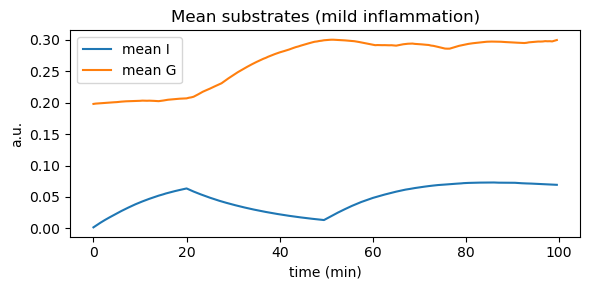

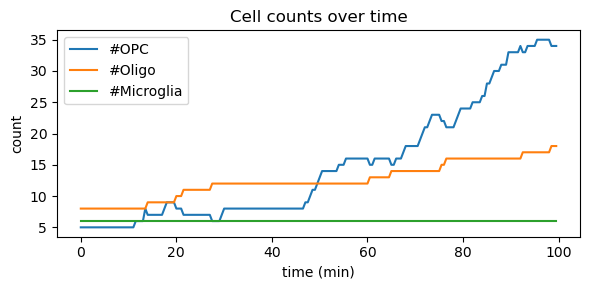

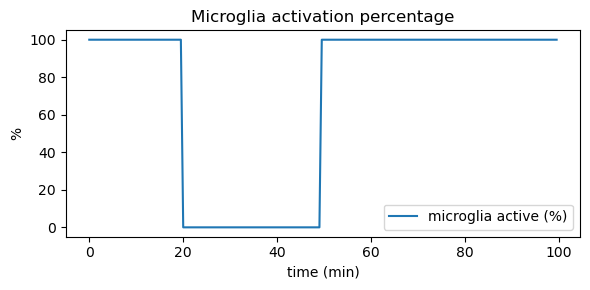

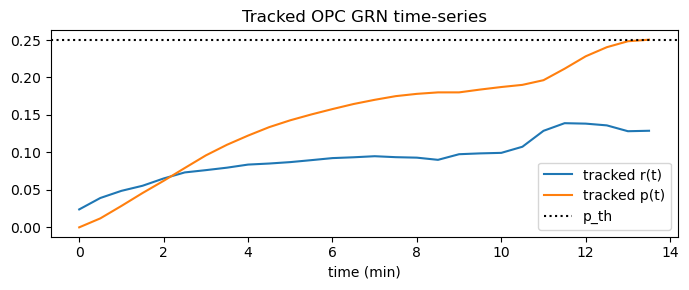

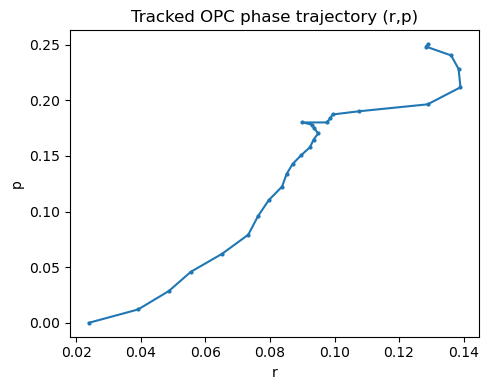

Saved GIF: sim.gif


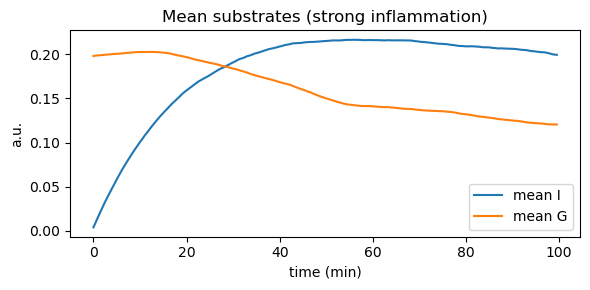

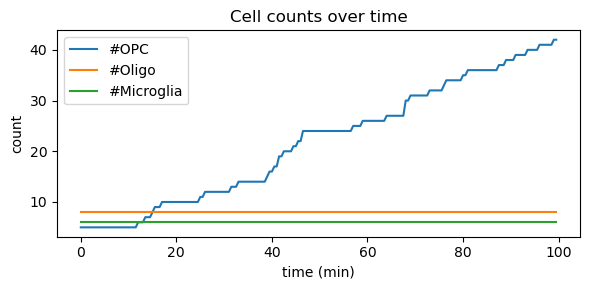

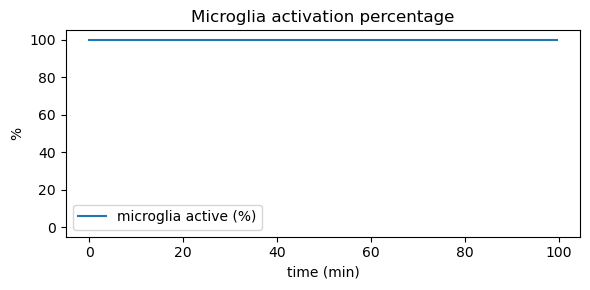

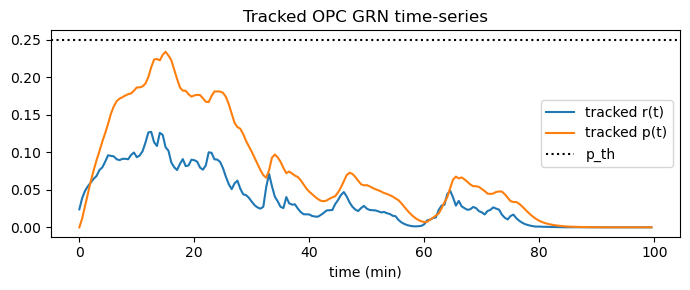

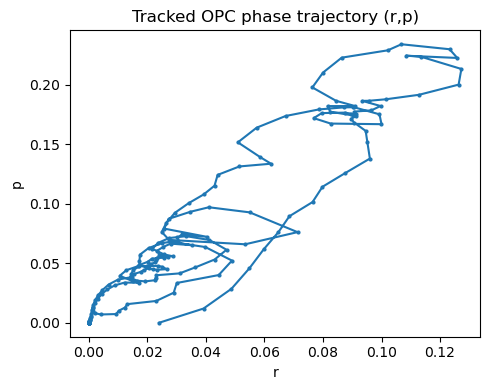

Saved GIF: sim.gif


{'t': array([ 0. ,  0.5,  1. ,  1.5,  2. ,  2.5,  3. ,  3.5,  4. ,  4.5,  5. ,
         5.5,  6. ,  6.5,  7. ,  7.5,  8. ,  8.5,  9. ,  9.5, 10. , 10.5,
        11. , 11.5, 12. , 12.5, 13. , 13.5, 14. , 14.5, 15. , 15.5, 16. ,
        16.5, 17. , 17.5, 18. , 18.5, 19. , 19.5, 20. , 20.5, 21. , 21.5,
        22. , 22.5, 23. , 23.5, 24. , 24.5, 25. , 25.5, 26. , 26.5, 27. ,
        27.5, 28. , 28.5, 29. , 29.5, 30. , 30.5, 31. , 31.5, 32. , 32.5,
        33. , 33.5, 34. , 34.5, 35. , 35.5, 36. , 36.5, 37. , 37.5, 38. ,
        38.5, 39. , 39.5, 40. , 40.5, 41. , 41.5, 42. , 42.5, 43. , 43.5,
        44. , 44.5, 45. , 45.5, 46. , 46.5, 47. , 47.5, 48. , 48.5, 49. ,
        49.5, 50. , 50.5, 51. , 51.5, 52. , 52.5, 53. , 53.5, 54. , 54.5,
        55. , 55.5, 56. , 56.5, 57. , 57.5, 58. , 58.5, 59. , 59.5, 60. ,
        60.5, 61. , 61.5, 62. , 62.5, 63. , 63.5, 64. , 64.5, 65. , 65.5,
        66. , 66.5, 67. , 67.5, 68. , 68.5, 69. , 69.5, 70. , 70.5, 71. ,
        71.5, 72. , 72.5, 73. , 7

In [ ]:
# Run mild vs strong and export GIFs
run_sim(regime="mild",gif_path="sim_mild.gif", seed=1)
run_sim(regime="strong", gif_path="sim_strong.gif",seed=1)